# 08 - A small, optional ML add-on

Second optional Stage 7 piece (user's choice). Per the plan's own framing,
ML here is "optional and last" - a simple, standard scikit-learn model, not
a research contribution or a diagnostic tool, and not something the
project's non-goals (no custom deep nets) would want anyway.

Task: given a spot's expression, predict whether it's `tumour_cold` or
`tumour_infiltrated` (notebook 05's two melanocytic compartments). This is
deliberately not a novel question - notebooks 05-06 already characterised
what separates them - the point is to check *how separable* they are in a
predictive sense, and specifically whether a classifier here would mostly
be learning the same sequencing-depth confound notebook 06 found, rather
than treating that as solved and moving on.

**The one thing done carefully, because this project already burned itself
on skipping it once:** spots from the same patient are not independent
(same lesson as "patient is the unit of replication" throughout this
project) - cross-validation is grouped by patient, never a plain random
spot-level split, which would leak information between train and test
through spatially/patient-correlated expression.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay

sys.path.insert(0, str(Path("..") / "src"))

TABLES_OUT = Path("..") / "results" / "tables"
FIGURES_OUT = Path("..") / "results" / "figures"
PROCESSED_OUT = Path("..") / "data" / "processed"

sc.settings.verbosity = 1
plt.rcParams["figure.facecolor"] = "white"
RANDOM_STATE = 0


## 1. Task setup: tumour_cold vs tumour_infiltrated, grouped by patient

In [2]:
combined = sc.read_h5ad(PROCESSED_OUT / "06_pathway.h5ad")
pair = combined[combined.obs["compartment"].isin(["tumour_cold", "tumour_infiltrated"])].copy()
y = (pair.obs["compartment"] == "tumour_infiltrated").astype(int).values
groups = pair.obs["patient"].values
X_pca = pair.obsm["X_pca"]

print(f"{pair.n_obs} spots ({(y==0).sum()} tumour_cold, {(y==1).sum()} tumour_infiltrated) "
      f"across {pair.obs['patient'].nunique()} patients")
print(f"features: {X_pca.shape[1]} PCA components (already computed in notebook 02, reused here)")


8019 spots (5795 tumour_cold, 2224 tumour_infiltrated) across 18 patients
features: 50 PCA components (already computed in notebook 02, reused here)


## 2. Cross-validated performance - grouped by patient, not by spot

5-fold, patients never split across train/test within a fold. Class
imbalance handled with `class_weight="balanced"` rather than resampling,
to keep this simple.

In [3]:
%%time
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))

pred_proba = cross_val_predict(clf, X_pca, y, cv=cv, groups=groups, method="predict_proba")[:, 1]
auc_full = roc_auc_score(y, pred_proba)
print(f"AUC (50 PCA components, patient-grouped CV): {auc_full:.3f}")
print(classification_report(y, pred_proba > 0.5, target_names=["tumour_cold", "tumour_infiltrated"]))


AUC (50 PCA components, patient-grouped CV): 0.989
                    precision    recall  f1-score   support

       tumour_cold       0.97      0.95      0.96      5795
tumour_infiltrated       0.88      0.93      0.91      2224

          accuracy                           0.95      8019
         macro avg       0.93      0.94      0.93      8019
      weighted avg       0.95      0.95      0.95      8019

CPU times: total: 250 ms
Wall time: 281 ms


## 3. The depth check this notebook exists to run

Notebook 06 found tumour_infiltrated has ~23x the sequencing depth of
tumour_cold. A classifier fed expression-derived features can trivially
exploit that instead of learning anything about the two compartments'
actual biology. Checked two ways: a depth-only baseline model, and the
same classifier on depth-*residualized* PCA features.

In [4]:
%%time
log_depth = np.log1p(pair.obs["total_counts"].values).reshape(-1, 1)
depth_only_clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE))
depth_pred = cross_val_predict(depth_only_clf, log_depth, y, cv=cv, groups=groups, method="predict_proba")[:, 1]
auc_depth_only = roc_auc_score(y, depth_pred)
print(f"AUC using ONLY log(total_counts) as a feature: {auc_depth_only:.3f}")
print(f"AUC using the full 50-PC model: {auc_full:.3f}")
print(f"-> the full model beats the depth-only baseline by {auc_full - auc_depth_only:.3f} AUC")


AUC using ONLY log(total_counts) as a feature: 0.894
AUC using the full 50-PC model: 0.989
-> the full model beats the depth-only baseline by 0.095 AUC
CPU times: total: 62.5 ms
Wall time: 65.7 ms


In [5]:
%%time
# residualize each PC against log-depth (fit on all paired spots), same method as notebook 06 section 3b
X_resid = np.zeros_like(X_pca)
for j in range(X_pca.shape[1]):
    slope, intercept = np.polyfit(log_depth.ravel(), X_pca[:, j], 1)
    X_resid[:, j] = X_pca[:, j] - (slope * log_depth.ravel() + intercept)

resid_pred = cross_val_predict(clf, X_resid, y, cv=cv, groups=groups, method="predict_proba")[:, 1]
auc_resid = roc_auc_score(y, resid_pred)
print(f"AUC using depth-RESIDUALIZED PCA features: {auc_resid:.3f}")
print(f"(full model {auc_full:.3f} -> depth-residualized {auc_resid:.3f}; "
      f"the drop is the part of the full model's performance depth alone could explain)")


AUC using depth-RESIDUALIZED PCA features: 0.665


(full model 0.989 -> depth-residualized 0.665; the drop is the part of the full model's performance depth alone could explain)
CPU times: total: 172 ms
Wall time: 185 ms


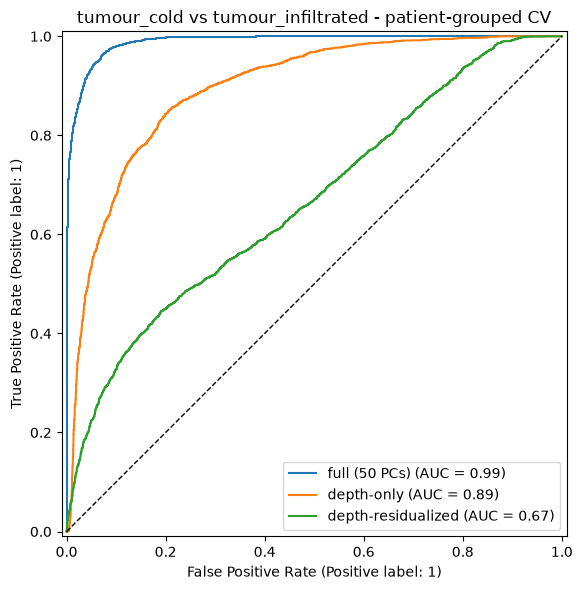

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, pred in [("full (50 PCs)", pred_proba), ("depth-only", depth_pred), ("depth-residualized", resid_pred)]:
    RocCurveDisplay.from_predictions(y, pred, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_title("tumour_cold vs tumour_infiltrated - patient-grouped CV")
plt.tight_layout()
plt.savefig(FIGURES_OUT / "08_roc_curves.png", dpi=150)
plt.show()


## 4. What's actually driving the (depth-adjusted) classifier

Which PCs matter, and which genes load onto them - refit on all the data
(no CV split needed here, this is about interpreting the model, not
estimating its performance) using the depth-residualized features, so this
reflects the part of the signal that survived the check in section 3.

In [7]:
final_clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
final_clf.fit(X_resid, y)
coefs = final_clf.named_steps["logisticregression"].coef_.ravel()
top_pcs = np.argsort(np.abs(coefs))[::-1][:5]

print("Top 5 most predictive PCs (after depth residualization) and their top +/- gene loadings:")
for pc in top_pcs:
    loadings = pd.Series(pair.varm["PCs"][:, pc], index=pair.var_names)
    top_pos = loadings.sort_values(ascending=False).head(5)
    top_neg = loadings.sort_values().head(5)
    print(f"\nPC{pc+1} (coef={coefs[pc]:+.3f}):")
    print(f"  + loadings: {top_pos.index.tolist()}")
    print(f"  - loadings: {top_neg.index.tolist()}")


Top 5 most predictive PCs (after depth residualization) and their top +/- gene loadings:

PC1 (coef=-0.983):
  + loadings: ['KRTDAP', 'KRT1', 'KRT10', 'FLG', 'KRT14']
  - loadings: ['MMP2', 'IGFBP5', 'TNXB', 'FBN1', 'PI16']

PC9 (coef=+0.616):
  + loadings: ['IGKC', 'IGHG1', 'DCD', 'MUCL1', 'JCHAIN']
  - loadings: ['PLIN4', 'G0S2', 'FABP4', 'PLIN1', 'HBA2']

PC20 (coef=+0.555):
  + loadings: ['FLG', 'HBA2', 'CST6', 'TCHH', 'DCD']
  - loadings: ['ADIRF', 'LY6D', 'COL17A1', 'SLPI', 'PI16']

PC2 (coef=+0.489):
  + loadings: ['MMP2', 'IGFBP5', 'TNXB', 'FBN1', 'IGKC']
  - loadings: ['HBA2', 'HBB', 'PLIN4', 'TCHH', 'KRT86']

PC7 (coef=-0.449):
  + loadings: ['KRT14', 'KRT15', 'COL17A1', 'KRT1', 'KRT10']
  - loadings: ['MYL9', 'S100A9', 'FABP4', 'TAGLN', 'S100A8']


## 5. Summary

In [8]:
summary = pd.DataFrame([
    {"model": "full (50 PCs)", "auc": auc_full},
    {"model": "depth-only baseline", "auc": auc_depth_only},
    {"model": "depth-residualized PCs", "auc": auc_resid},
])
summary.to_csv(TABLES_OUT / "ml_addon_auc_comparison.csv", index=False)
print("Observed, from this notebook's own computation:")
print(summary.to_string(index=False))
print(f"\n{pair.obs['patient'].nunique()} patients, 5-fold patient-grouped CV throughout")


Observed, from this notebook's own computation:
                 model      auc
         full (50 PCs) 0.989109
   depth-only baseline 0.894163
depth-residualized PCs 0.665235

18 patients, 5-fold patient-grouped CV throughout


**How to read the three AUC numbers above, honestly:** if the
depth-only baseline is already close to the full model's AUC, most of what
looks like "the classifier learned to tell these compartments apart" is
really "the classifier learned to detect depth" - exactly the notebook 06
confound, now visible in a predictive-performance number instead of a
p-value. The depth-residualized AUC is the more honest estimate of what's
left once that's accounted for - still likely above chance (0.5), since
section 4's top gene loadings should echo notebook 06's real, depth-
independent findings (the keratin/epidermal vs immune-receptor genes) if
this model is picking up genuine signal rather than noise.

**What this notebook is not:** a diagnostic or clinical tool, a novel
modelling contribution, or evidence for a specific pathway mechanism -
it's a simple, standard classifier used to quantify separability and
re-surface the same depth confound in a different form, exactly as
planned when this was scoped as "optional and last".